# MWE 34 - Macro/micro synthetic porous image

This notebook demonstrates the macro/micro synthetic image generator in
`voids`. The construction uses two PoreSpy `blobs` fields:

- a resolved macropore field
- a smaller-feature micropore field that is clipped to the matrix phase of the
  macropore image

The example generates a `200^3` binary volume, visualizes representative
slices, and exports the image volume with explicit voxel-size metadata.

Scientific scope and assumptions:

- `True` denotes void and `False` denotes solid or matrix
- the image is synthetic and is not calibrated to a specific rock sample
- matrix micropores are resolved as small binary features in this toy image
- `matrix_microporosity` is measured only inside the macropore matrix
- exported voxel formats store or accompany the physical voxel size, because
  formats such as raw, NumPy, and TIFF do not reliably define 3-D voxel
  resolution on their own

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

from voids.generators import generate_macro_micro_blobs_matrix
from voids.io import VolumeData, load_volume_data, save_volume_bundle


def _find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "mkdocs.yml").exists() and (candidate / "notebooks").exists():
            return candidate
    return cwd


def _relative_to_root(path: Path, root: Path) -> str:
    try:
        return str(path.relative_to(root))
    except ValueError:
        return str(path)

## Configuration

The editable controls below set the volume size, porosity targets, feature
scales, deterministic seed stream, and physical voxel size. Larger PoreSpy
`blobiness` values create smaller features, so the micropore field uses a
larger value than the macropore field.

In [2]:
project_root = _find_project_root()
output_dir = (
    project_root / "notebooks" / "outputs" / "34_mwe_macro_micro_synthetic_case"
)
output_dir.mkdir(parents=True, exist_ok=True)

shape = (200, 200, 200)
macro_porosity_target = 0.25
matrix_microporosity_target = 0.12
macro_blobiness = 1.4
micropore_blobiness = 10.0
seed_start = 2026
max_tries = 30
axis_index = 0
periodic = True

voxel_size_m = (40.0e-6, 40.0e-6, 40.0e-6)
length_units = {"length": "m"}

output_dir

PosixPath('/Users/dtvolpatto/Work/voids/notebooks/outputs/34_mwe_macro_micro_synthetic_case')

## Generate the macro/micro image

`axis_index=0` asks the generator to accept only realizations where the
combined void space spans through axis 0. The returned object keeps the three
masks separate: `macro_void`, `micropore_void`, and their union `void`.

In [3]:
case = generate_macro_micro_blobs_matrix(
    shape=shape,
    macro_porosity=macro_porosity_target,
    matrix_microporosity=matrix_microporosity_target,
    macro_blobiness=macro_blobiness,
    micropore_blobiness=micropore_blobiness,
    seed_start=seed_start,
    max_tries=max_tries,
    axis_index=axis_index,
    periodic=periodic,
)

realized_total_from_components = (
    case.macro_porosity + (1.0 - case.macro_porosity) * case.matrix_microporosity
)
target_total_porosity = (
    macro_porosity_target + (1.0 - macro_porosity_target) * matrix_microporosity_target
)

summary = {
    "shape": case.shape,
    "target_total_porosity": target_total_porosity,
    "realized_total_porosity": case.porosity,
    "realized_total_from_components": realized_total_from_components,
    "realized_macro_porosity": case.macro_porosity,
    "realized_matrix_microporosity": case.matrix_microporosity,
    "realized_total_microporosity": case.total_microporosity,
    "macro_seed": case.metadata["macro_seed"],
    "micropore_seed": case.metadata["micropore_seed"],
}

for key, value in summary.items():
    print(f"{key}: {value}")

shape: (200, 200, 200)
target_total_porosity: 0.33999999999999997
realized_total_porosity: 0.34
realized_total_from_components: 0.33999999999999997
realized_macro_porosity: 0.25
realized_matrix_microporosity: 0.12
realized_total_microporosity: 0.09
macro_seed: 2026
micropore_seed: 2027


## Build a phase-coded image for visualization

The phase-coded image below uses:

- 0: matrix/solid
- 1: resolved macropore void
- 2: matrix-hosted micropore void

In [4]:
phase = np.zeros(case.shape, dtype=np.uint8)
phase[case.macro_void] = 1
phase[case.micropore_void] = 2

phase_cmap = ListedColormap(["#e8e8e8", "#2878b5", "#f28e2b"])
phase_legend = [
    Patch(facecolor="#e8e8e8", edgecolor="black", label="matrix / solid"),
    Patch(facecolor="#2878b5", edgecolor="black", label="macropore void"),
    Patch(facecolor="#f28e2b", edgecolor="black", label="matrix micropore void"),
]

## Show representative slices

The top row shows the combined binary void image. The bottom row separates
macropores from matrix micropores so the two porosity scales remain
interpretable.

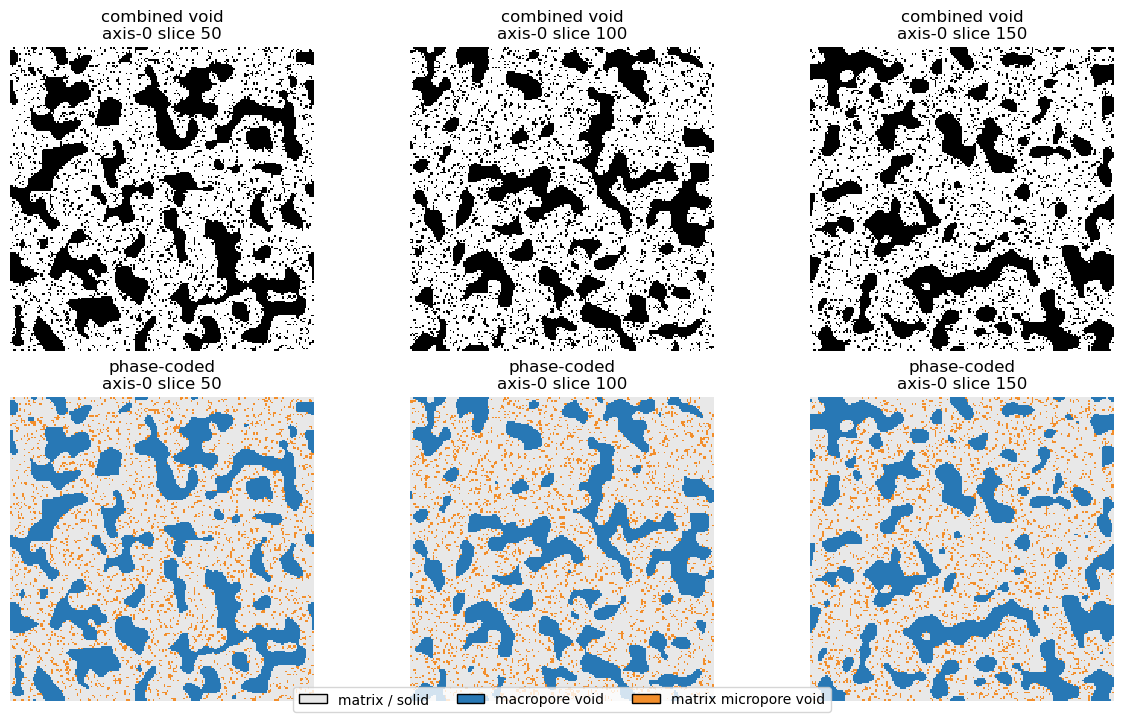

Saved slice figure: notebooks/outputs/34_mwe_macro_micro_synthetic_case/macro_micro_slices.png


In [5]:
slice_indices = [shape[0] // 4, shape[0] // 2, 3 * shape[0] // 4]

fig, axes = plt.subplots(
    2,
    len(slice_indices),
    figsize=(12, 7),
    constrained_layout=True,
)

for column, index in enumerate(slice_indices):
    axes[0, column].imshow(case.void[index], cmap="gray_r", interpolation="nearest")
    axes[0, column].set_title(f"combined void\naxis-0 slice {index}")
    axes[0, column].set_axis_off()

    axes[1, column].imshow(
        phase[index], cmap=phase_cmap, vmin=0, vmax=2, interpolation="nearest"
    )
    axes[1, column].set_title(f"phase-coded\naxis-0 slice {index}")
    axes[1, column].set_axis_off()

fig.legend(
    handles=phase_legend, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02)
)
slice_figure = output_dir / "macro_micro_slices.png"
fig.savefig(slice_figure, dpi=180, bbox_inches="tight")
plt.show()

print("Saved slice figure:", _relative_to_root(slice_figure, project_root))

## Zoom into the central slice

The smaller matrix-hosted pores are easier to inspect in a cropped view. The
crop below compares the macropore mask, micropore mask, and combined void mask.

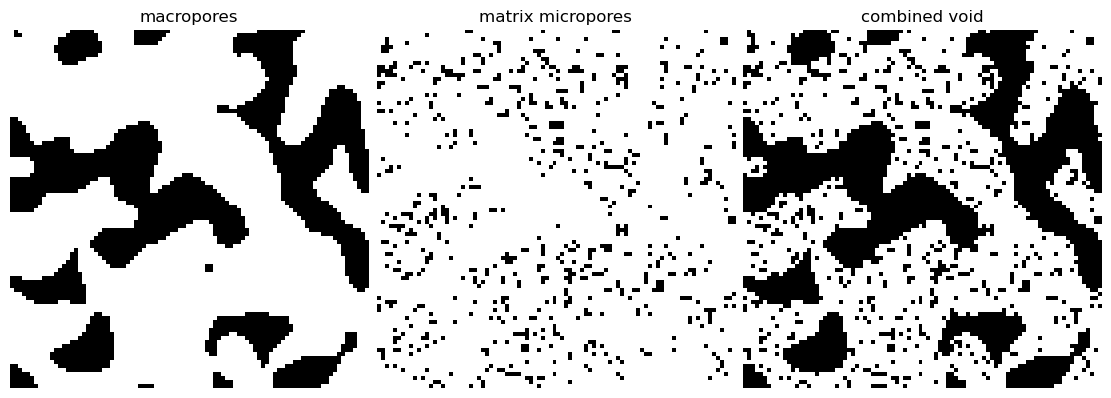

Saved zoom figure: notebooks/outputs/34_mwe_macro_micro_synthetic_case/macro_micro_zoom.png


In [6]:
center = shape[1] // 2
half_width = 45
window = (
    slice(center - half_width, center + half_width),
    slice(center - half_width, center + half_width),
)
central_slice = shape[0] // 2

zoom_panels = [
    ("macropores", case.macro_void[central_slice][window]),
    ("matrix micropores", case.micropore_void[central_slice][window]),
    ("combined void", case.void[central_slice][window]),
]

fig, axes = plt.subplots(1, 3, figsize=(11, 4), constrained_layout=True)
for ax, (title, image) in zip(axes, zoom_panels, strict=True):
    ax.imshow(image, cmap="gray_r", interpolation="nearest")
    ax.set_title(title)
    ax.set_axis_off()

zoom_figure = output_dir / "macro_micro_zoom.png"
fig.savefig(zoom_figure, dpi=180, bbox_inches="tight")
plt.show()

print("Saved zoom figure:", _relative_to_root(zoom_figure, project_root))

## Check porosity by slice

Slice-wise porosity is a quick diagnostic for gross anisotropy or unexpected
phase placement. The total porosity combines macropores and matrix-hosted
micropores.

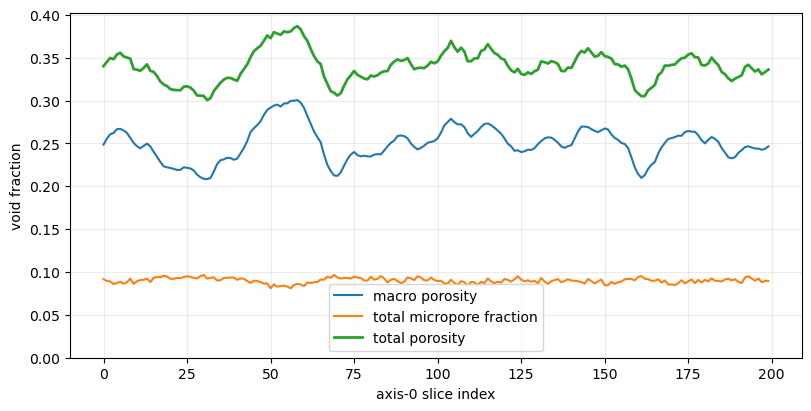

Saved porosity profile: notebooks/outputs/34_mwe_macro_micro_synthetic_case/macro_micro_porosity_profile.png


In [7]:
slice_axis = (1, 2)
macro_phi_by_slice = case.macro_void.mean(axis=slice_axis)
micro_phi_by_slice = case.micropore_void.mean(axis=slice_axis)
total_phi_by_slice = case.void.mean(axis=slice_axis)

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.plot(macro_phi_by_slice, label="macro porosity")
ax.plot(micro_phi_by_slice, label="total micropore fraction")
ax.plot(total_phi_by_slice, label="total porosity", linewidth=2)
ax.set_xlabel("axis-0 slice index")
ax.set_ylabel("void fraction")
ax.set_ylim(bottom=0.0)
ax.grid(True, alpha=0.25)
ax.legend()

profile_figure = output_dir / "macro_micro_porosity_profile.png"
fig.savefig(profile_figure, dpi=180, bbox_inches="tight")
plt.show()

print("Saved porosity profile:", _relative_to_root(profile_figure, project_root))

## Export the image volume

The exported object stores the binary volume plus voxel resolution metadata.
The voxel formats below are suitable for reloading into `voids` or passing to
external image-processing and continuum-solver workflows. Raw, NumPy, and TIFF
exports are accompanied by JSON sidecars because those files do not reliably
encode full 3-D voxel-size metadata by themselves.

In [8]:
volume_data = VolumeData(
    values=case.void,
    voxel_size=voxel_size_m,
    units=length_units,
    metadata={
        **case.metadata,
        "true_phase": "void",
        "false_phase": "solid_or_matrix",
        "target_total_porosity": target_total_porosity,
        "realized_total_porosity": case.porosity,
        "realized_macro_porosity": case.macro_porosity,
        "realized_matrix_microporosity": case.matrix_microporosity,
    },
)

written = save_volume_bundle(
    volume_data,
    output_dir,
    stem="macro_micro_200",
    formats=("raw", "npy", "h5", "nc", "tiff"),
)

for fmt, path in written.items():
    size_mib = path.stat().st_size / 1024**2
    print(f"{fmt:>4}: {_relative_to_root(path, project_root)} ({size_mib:.2f} MiB)")
    sidecar = path.with_suffix(path.suffix + ".json")
    if sidecar.exists():
        print(f"      sidecar: {_relative_to_root(sidecar, project_root)}")

 raw: notebooks/outputs/34_mwe_macro_micro_synthetic_case/macro_micro_200.raw (7.63 MiB)
      sidecar: notebooks/outputs/34_mwe_macro_micro_synthetic_case/macro_micro_200.raw.json
 npy: notebooks/outputs/34_mwe_macro_micro_synthetic_case/macro_micro_200.npy (7.63 MiB)
      sidecar: notebooks/outputs/34_mwe_macro_micro_synthetic_case/macro_micro_200.npy.json
  h5: notebooks/outputs/34_mwe_macro_micro_synthetic_case/macro_micro_200.h5 (7.64 MiB)
  nc: notebooks/outputs/34_mwe_macro_micro_synthetic_case/macro_micro_200.nc (15.26 MiB)
tiff: notebooks/outputs/34_mwe_macro_micro_synthetic_case/macro_micro_200.tiff (7.66 MiB)
      sidecar: notebooks/outputs/34_mwe_macro_micro_synthetic_case/macro_micro_200.tiff.json


## Reload and verify metadata

This check verifies that the exported TIFF stack can be reloaded with the
physical voxel size preserved by the `voids` sidecar. For external TIFF stacks
without a sidecar, pass `voxel_size=...` explicitly to `load_volume_data`.

In [9]:
reloaded = load_volume_data(written["tiff"])

assert reloaded.shape == case.shape
assert reloaded.voxel_size == voxel_size_m
assert reloaded.units == length_units
assert np.array_equal(reloaded.values.astype(bool), case.void)

print("Reloaded TIFF shape:", reloaded.shape)
print("Reloaded voxel size:", reloaded.voxel_size, reloaded.units)
print("Reloaded porosity:", float(reloaded.values.astype(bool).mean()))

Reloaded TIFF shape: (200, 200, 200)
Reloaded voxel size: (4e-05, 4e-05, 4e-05) {'length': 'm'}
Reloaded porosity: 0.34


## Compare original and reloaded slices

The comparison below plots the original combined void mask, the reloaded TIFF
mask, and their mismatch mask for the same representative slices. A fully
white mismatch row means the exported/reloaded binary image is identical to
the generated image for those slices; the array equality assertion above
verifies this for the full 3-D volume.

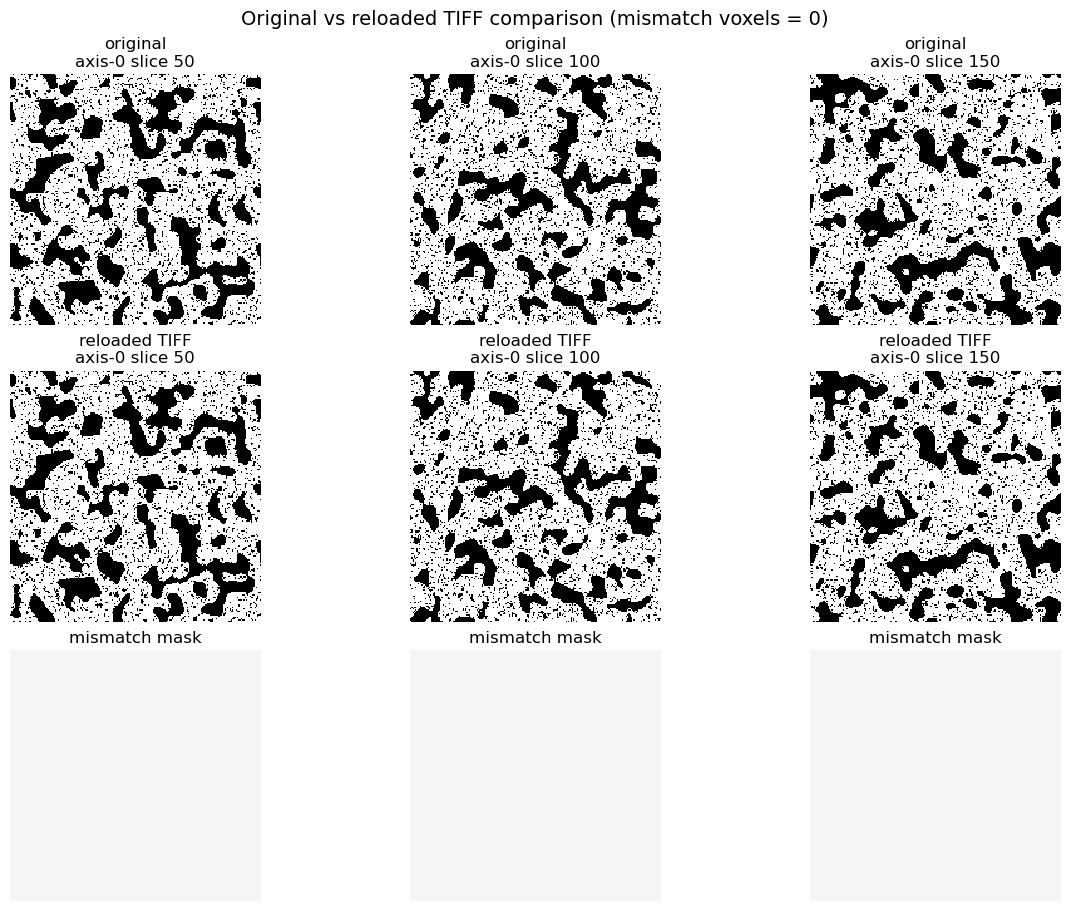

Mismatch voxels: 0
Saved reload comparison: notebooks/outputs/34_mwe_macro_micro_synthetic_case/macro_micro_reloaded_comparison.png


In [10]:
reloaded_void = reloaded.values.astype(bool)
mismatch = np.logical_xor(case.void, reloaded_void)
mismatch_count = int(np.count_nonzero(mismatch))
mismatch_cmap = ListedColormap(["#f5f5f5", "#d62728"])

fig, axes = plt.subplots(
    3,
    len(slice_indices),
    figsize=(12, 9),
    constrained_layout=True,
)
fig.suptitle(
    f"Original vs reloaded TIFF comparison (mismatch voxels = {mismatch_count})",
    fontsize=14,
)

for column, index in enumerate(slice_indices):
    axes[0, column].imshow(case.void[index], cmap="gray_r", interpolation="nearest")
    axes[0, column].set_title(f"original\naxis-0 slice {index}")
    axes[0, column].set_axis_off()

    axes[1, column].imshow(
        reloaded_void[index],
        cmap="gray_r",
        interpolation="nearest",
    )
    axes[1, column].set_title(f"reloaded TIFF\naxis-0 slice {index}")
    axes[1, column].set_axis_off()

    axes[2, column].imshow(
        mismatch[index],
        cmap=mismatch_cmap,
        vmin=0,
        vmax=1,
        interpolation="nearest",
    )
    axes[2, column].set_title("mismatch mask")
    axes[2, column].set_axis_off()

comparison_figure = output_dir / "macro_micro_reloaded_comparison.png"
fig.savefig(comparison_figure, dpi=180, bbox_inches="tight")
plt.show()

print("Mismatch voxels:", mismatch_count)
print("Saved reload comparison:", _relative_to_root(comparison_figure, project_root))